In [3]:
from google.colab import files
uploaded = files.upload()

Saving AirQuality.csv to AirQuality.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [13]:
# Replace with your uploaded file name EXACTLY
df = pd.read_csv("AirQuality.csv", sep=';')

print(df.head())
print(df.info())

         Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT) C6H6(GT)  PT08.S2(NMHC)  \
0  10/03/2004  18.00.00    2,6       1360.0     150.0     11,9         1046.0   
1  10/03/2004  19.00.00      2       1292.0     112.0      9,4          955.0   
2  10/03/2004  20.00.00    2,2       1402.0      88.0      9,0          939.0   
3  10/03/2004  21.00.00    2,2       1376.0      80.0      9,2          948.0   
4  10/03/2004  22.00.00    1,6       1272.0      51.0      6,5          836.0   

   NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
0    166.0        1056.0    113.0        1692.0       1268.0  13,6  48,9   
1    103.0        1174.0     92.0        1559.0        972.0  13,3  47,7   
2    131.0        1140.0    114.0        1555.0       1074.0  11,9  54,0   
3    172.0        1092.0    122.0        1584.0       1203.0  11,0  60,0   
4    131.0        1205.0    116.0        1490.0       1110.0  11,2  59,6   

       AH  Unnamed: 15  Unnamed: 16  
0  0,7578         

In [7]:
print(df.columns)

Index(['Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;'], dtype='object')


In [8]:
# Example (edit if needed)
df.rename(columns={'Date': 'date', 'AQI_Value': 'AQI'}, inplace=True)

In [14]:
# Remove completely empty columns
df = df.dropna(axis=1, how='all')

In [16]:
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')

In [17]:
df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

In [18]:
df.replace(-200, pd.NA, inplace=True)
df = df.fillna(method='ffill')

/tmp/ipykernel_10947/3086584990.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_10947/3086584990.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(method='ffill')


In [20]:
import pandas as pd

# Load dataset correctly (semicolon-separated)
df = pd.read_csv("AirQuality.csv", sep=';')

# Remove empty columns
df = df.dropna(axis=1, how='all')

# Check columns
print(df.columns)

# Combine Date + Time into datetime
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')

# Sort and set index
df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

# Replace -200 (missing values) and fill
df.replace(-200, pd.NA, inplace=True)
df = df.fillna(method='ffill')

# Final check
print(df.head())
print(df.isnull().sum())

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')
                           Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT)  \
datetime                                                                  
2004-03-10 18:00:00  10/03/2004  18.00.00    2,6       1360.0     150.0   
2004-03-10 19:00:00  10/03/2004  19.00.00      2       1292.0     112.0   
2004-03-10 20:00:00  10/03/2004  20.00.00    2,2       1402.0      88.0   
2004-03-10 21:00:00  10/03/2004  21.00.00    2,2       1376.0      80.0   
2004-03-10 22:00:00  10/03/2004  22.00.00    1,6       1272.0      51.0   

                    C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  \
datetime                                                                      
2004-03-10 18:00:00     11,9         1046.0    166.0        1056.0    113.0   
2004-03-10 19:00:00      

/tmp/ipykernel_10947/569922535.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_10947/569922535.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(method='ffill')


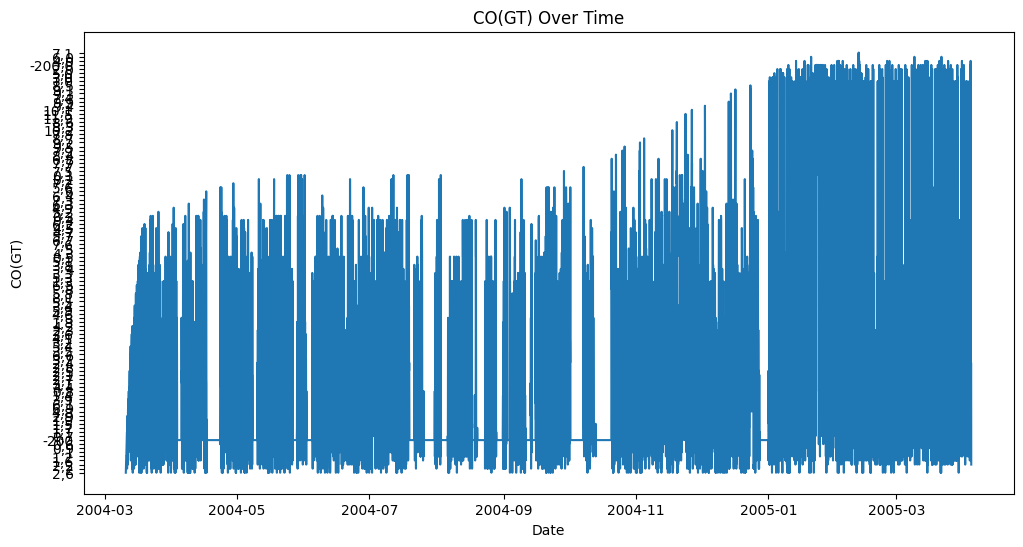

In [22]:
plt.figure(figsize=(12,6))
plt.plot(df['CO(GT)'])
plt.title("CO(GT) Over Time")
plt.xlabel("Date")
plt.ylabel("CO(GT)")
plt.show()

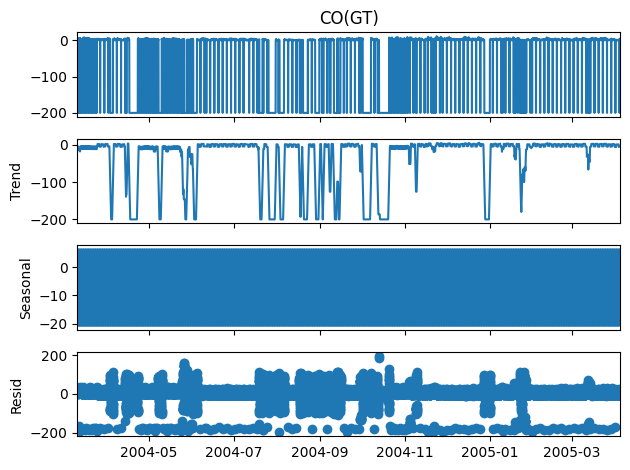

In [26]:
df['CO(GT)'] = df['CO(GT)'].astype(str).str.replace(',', '.', regex=False).astype(float)
# Remove rows with NaT in the datetime index to ensure a clean time series
df_clean = df.dropna(subset=['CO(GT)']).copy()
# Ensure the index is a proper DatetimeIndex without NaT
df_clean = df_clean[df_clean.index.notna()]
decomposition = seasonal_decompose(df_clean['CO(GT)'], model='additive', period=30)
decomposition.plot()
plt.show()

In [28]:
result = adfuller(df['CO(GT)'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is NOT Stationary")

ADF Statistic: -9.589999679380837
p-value: 2.0481531689516092e-16
Data is Stationary


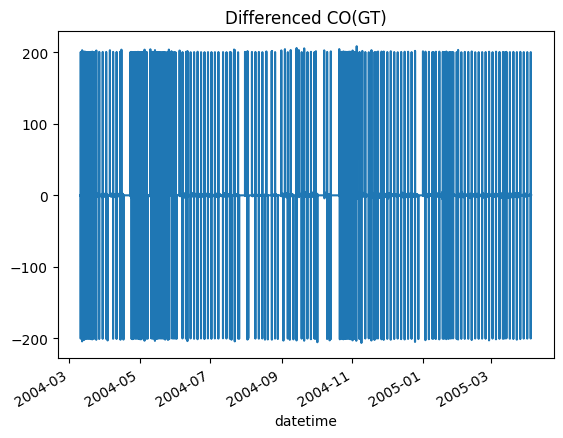

In [31]:
df['CO(GT)_diff'] = df['CO(GT)'].diff()

df['CO(GT)_diff'].plot()
plt.title("Differenced CO(GT)")
plt.show()

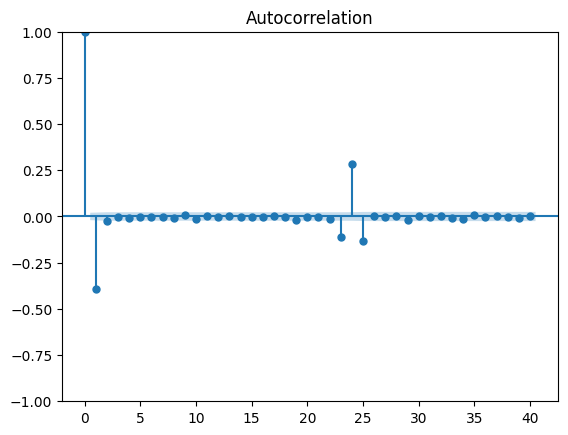

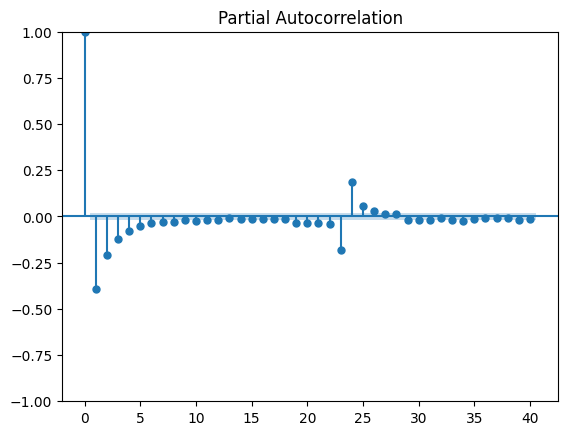

In [37]:
plot_acf(df['CO(GT)_diff'].dropna())
plot_pacf(df['CO(GT)_diff'].dropna())
plt.show()

In [39]:
model = ARIMA(df['CO(GT)'], order=(1,1,1))  # You can tune (p,d,q)
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

                               SARIMAX Results                                
Dep. Variable:                 CO(GT)   No. Observations:                 9471
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -47247.227
Date:                Fri, 24 Apr 2026   AIC                          94500.455
Time:                        06:25:39   BIC                          94521.922
Sample:                             0   HQIC                         94507.741
                               - 9471                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1044      0.012      8.496      0.000       0.080       0.129
ma.L1         -0.6178      0.011    -55.057      0.000      -0.640      -0.596
sigma2      1261.8128      5.316    237.360      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


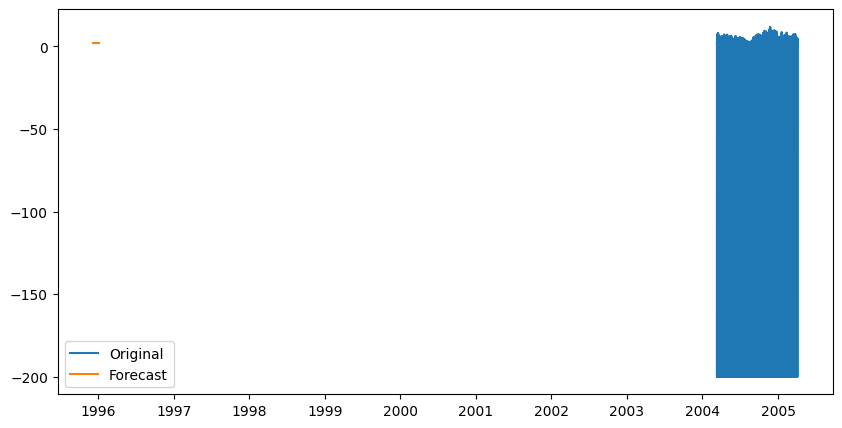

In [41]:
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(df['CO(GT)'], label='Original')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.show()

In [43]:
train = df['CO(GT)'][:-30]
test = df['CO(GT)'][-30:]

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

pred = model_fit.forecast(steps=30)

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = np.mean(np.abs((test - pred) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

MAE: 4.440892098500626e-16
RMSE: 4.440892098500626e-16
MAPE: nan


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [44]:
forecast.to_csv("aqi_forecast.csv")

from google.colab import files
files.download("aqi_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>